In [1]:
#Step 1 : Data Sanity Checks
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("/Users/mohanrajsubramaniam/PycharmProjects/python_learning/Pandas/datafiles/Melbourne_Housing.csv")
data.head()
print(data.head())
print(data.tail())


         Suburb  Rooms Type        SellerG        Date  Distance  Postcode  \
0  Airport West      3    t         Nelson  03-09-2016      13.5    3042.0   
1   Albert Park      2    h  hockingstuart  03-09-2016       3.3    3206.0   
2   Albert Park      2    h        Thomson  03-09-2016       3.3    3206.0   
3    Alphington      4    h          Brace  03-09-2016       6.4    3078.0   
4    Alphington      3    h         Jellis  03-09-2016       6.4    3078.0   

   Bedroom  Bathroom  Car  Landsize BuildingArea  YearBuilt  \
0      3.0       2.0  1.0     303.0          225     2016.0   
1      2.0       1.0  0.0     120.0           82     1900.0   
2      2.0       1.0  0.0     159.0          inf        NaN   
3      3.0       2.0  4.0     853.0          263     1930.0   
4      3.0       2.0  2.0     208.0          inf     2013.0   

              Regionname  Propertycount    Price  
0   Western Metropolitan           3464   840000  
1  Southern Metropolitan           3280  1275000  

In [2]:
# print(data.shape())
# Shape provide rows and columns
# shape() requires parameters if parameter missed, TypeError: 'tuple' object is not callable
# share[0] -- number of rows , Shape[1] - number of columns
print(f'This dataset contains {data.shape[0]} rows and {data.shape[1]} columns' )

This dataset contains 27114 rows and 16 columns


In [3]:
data.info()
#4.1 Sanity Checks
#4.2 Univariate Analysis
#4.3 Bivariate Analysis
#4.4 Missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27114 entries, 0 to 27113
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         27114 non-null  object 
 1   Rooms          27114 non-null  int64  
 2   Type           27114 non-null  object 
 3   SellerG        27114 non-null  object 
 4   Date           27114 non-null  object 
 5   Distance       27113 non-null  float64
 6   Postcode       27113 non-null  float64
 7   Bedroom        20678 non-null  float64
 8   Bathroom       20672 non-null  float64
 9   Car            20297 non-null  float64
 10  Landsize       17873 non-null  float64
 11  BuildingArea   10543 non-null  object 
 12  YearBuilt      11985 non-null  float64
 13  Regionname     27114 non-null  object 
 14  Propertycount  27114 non-null  int64  
 15  Price          27114 non-null  int64  
dtypes: float64(7), int64(3), object(6)
memory usage: 3.3+ MB


In [4]:
# identify the number of numeric columns vs Object types
# this dataset contains 10 numeric columns and 6 object type columns
# why building area is reported as object???
#Cgabgubg data type of Date column
#data['Date'] = pd.to_datetime(data['Date'])

In [5]:
data['BuildingArea'].unique()

array(['225', '82', 'inf', '263', '242', '251', '117', 'missing', '76',
       '399', '118', '103', '180', '123', '218', '129', '167', '154',
       '275', '121', nan, '125', '255', '75', '156', '240', '268', '108',
       '69', '140', '214', '253', '189', '215', '96', '104', '100', '313',
       '144', '93', '110', '70', '122', '51', '147', '113', '83', '56',
       '137', '85', '64', '175', '3558', '170', '265', '353', '138', '19',
       '116', '87', '74', '320', '300', '210', '120', '86', '97', '200',
       '106', '14', '161', '128', '185', '146', '133', '115', '143',
       '150', '195', '236', '276', '188', '179', '249', '141', '34', '73',
       '107', '84', '81', '207', '50', '264', '312', '235', '221', '183',
       '132', '160', '186', '78', '105', '145', '62', '220', '315', '181',
       '61', '112', '420', '226', '266', '410', '449', '356', '477',
       '250', '95', '190', '284', '247', '213', '209', '119', '111',
       '130', '348', '166', '44', '176', '98', '159', '79'

# There are a few non-numerical values are present in Building area columns which is incorrect. So, we must replace these values in to numerical representation
# Default numerical value are 'nan' which is null in python ; Covert inf, and missing to 'nan'
# Convert non-numeric values in col to NaN. NaN --> means Not a Number
# Before apply the conversion lets get the statistical

In [6]:
data['BuildingArea'].apply(type).value_counts()

BuildingArea
<class 'float'>    16571
<class 'str'>      10543
Name: count, dtype: int64

There are 16,571 records are numeric and 10543 records are non-numeric

In [7]:
#replace the missing value to NaN
data["BuildingArea"] = data['BuildingArea'].replace(['missing','inf'],np.nan)

# Change the data type of BuildingArea
data['BuildingArea'] = data['BuildingArea'].astype(float)

In [8]:
#Read again
data.info() # BuildingArea   10529 non-null  float64 -- converted

data['Date'] = pd.to_datetime(data['Date'],format='%d-%m-%Y')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27114 entries, 0 to 27113
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         27114 non-null  object 
 1   Rooms          27114 non-null  int64  
 2   Type           27114 non-null  object 
 3   SellerG        27114 non-null  object 
 4   Date           27114 non-null  object 
 5   Distance       27113 non-null  float64
 6   Postcode       27113 non-null  float64
 7   Bedroom        20678 non-null  float64
 8   Bathroom       20672 non-null  float64
 9   Car            20297 non-null  float64
 10  Landsize       17873 non-null  float64
 11  BuildingArea   10529 non-null  float64
 12  YearBuilt      11985 non-null  float64
 13  Regionname     27114 non-null  object 
 14  Propertycount  27114 non-null  int64  
 15  Price          27114 non-null  int64  
dtypes: float64(8), int64(3), object(5)
memory usage: 3.3+ MB
<class 'pandas.core.frame.DataFrame'>

In [9]:
data['Bedroom'].unique()

array([ 3.,  2.,  5., nan,  4.,  1.,  6.,  7.,  0., 20.,  8.,  9., 12.,
       10., 16.])

In [10]:
#data['Bedroom'] = data['Bedroom'].apply(int).to_values()
#display data type
data['BuildingArea'].dtype

dtype('float64')

In [11]:
# Quiz
#1. Which of the following method is used to convert an object datatype column present in a pandas dataframe to the datetime datatype? Ans. pd.to_datetime()
#2. The default numerical value for a missing value is NaN (Not a number). Ans: True
#3. Use method data = pd.read_csv('data.csv', .....) replace mising values  Ans: na_values= ['inf','missing','unknow']
#4  which method is used to display unique values? Ans: dataframe['Column'].unique()

In [12]:
# What are the missing values ? Missing values occur when no data value is stored for the variable in an observation. Missing data are a common occuraence and can have a significant effect on the conclusions that can be drawn from the data.
# How to check for the missing values in the dataset
data.isnull().sum() # this method runs null check on all columns


Suburb               0
Rooms                0
Type                 0
SellerG              0
Date                 0
Distance             1
Postcode             1
Bedroom           6436
Bathroom          6442
Car               6817
Landsize          9241
BuildingArea     16585
YearBuilt        15129
Regionname           0
Propertycount        0
Price                0
dtype: int64

In [13]:
# Observation -  There are missing value in 8 columns of the data.
# How to check for duplicates?
data.duplicated().sum()

np.int64(11)

In [14]:
# There are 11 duplicate entries
data.drop_duplicates(inplace=True) #
data.reset_index(drop=True,inplace=True)

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27103 entries, 0 to 27102
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Suburb         27103 non-null  object        
 1   Rooms          27103 non-null  int64         
 2   Type           27103 non-null  object        
 3   SellerG        27103 non-null  object        
 4   Date           27103 non-null  datetime64[ns]
 5   Distance       27102 non-null  float64       
 6   Postcode       27102 non-null  float64       
 7   Bedroom        20678 non-null  float64       
 8   Bathroom       20672 non-null  float64       
 9   Car            20297 non-null  float64       
 10  Landsize       17873 non-null  float64       
 11  BuildingArea   10529 non-null  float64       
 12  YearBuilt      11985 non-null  float64       
 13  Regionname     27103 non-null  object        
 14  Propertycount  27103 non-null  int64         
 15  Price          2710

In [16]:
# 11 duplicate rows are removed
data.describe().T

,count,mean,min,25%,50%,75%,max,std
Rooms,27103.0,2.992473,1.0,2.0,3.0,4.0,16.0,0.954667
Date,27103,2017-05-23 12:25:09.441759488,2016-01-28 00:00:00,2016-11-19 00:00:00,2017-07-08 00:00:00,2017-10-28 00:00:00,2018-03-17 00:00:00,NaN
Distance,27102.0,11.279931,0.0,6.4,10.5,14.0,48.1,6.783958
Postcode,27102.0,3113.787322,3000.0,3046.0,3088.0,3153.0,3978.0,111.129025
Bedroom,20678.0,3.046184,0.0,2.0,3.0,4.0,20.0,0.955024
Bathroom,20672.0,1.591525,0.0,1.0,1.0,2.0,9.0,0.701106
Car,20297.0,1.71582,0.0,1.0,2.0,2.0,18.0,0.994487
Landsize,17873.0,560.536564,50.0,220.0,513.0,664.0,76000.0,1411.309127
BuildingArea,10529.0,154.511857,11.0,101.0,133.0,183.0,6791.0,130.583872
YearBuilt,11985.0,1966.618273,1850.0,1950.0,1970.0,2000.0,2019.0,36.042


In [17]:
data['Postcode'].nunique()

209

In [18]:
# list of categoorical variables
cat_cols = ['Suburb','Type','SellerG','Postcode','Regionname']
#Priting the cound of unique categorical levels in each colum
for col in cat_cols:
    print(data[col].value_counts())
    print("_"*50)

Suburb
Reservoir         724
Bentleigh East    493
Richmond          437
Preston           410
Brunswick         383
                 ... 
Wandin North        1
Ferny Creek         1
Tecoma              1
Montrose            1
viewbank            1
Name: count, Length: 345, dtype: int64
__________________________________________________
Type
h    18394
u     5882
t     2827
Name: count, dtype: int64
__________________________________________________
SellerG
Nelson           2733
Jellis           2516
Barry            2385
hockingstuart    2096
Ray              1574
                 ... 
Allan               1
Jim                 1
iProperty           1
Batty               1
Icon                1
Name: count, Length: 347, dtype: int64
__________________________________________________
Postcode
3073.0    724
3020.0    543
3046.0    540
3165.0    493
3121.0    487
         ... 
3770.0      1
3765.0      1
3775.0      1
3160.0      1
3793.0      1
Name: count, Length: 209, dtype: int64
____

In [19]:
# Printing the percentage of the unique categorical levels in each column
for col in cat_cols:
    print(data[col].value_counts(normalize=True))
    print("_"*50)

Suburb
Reservoir         0.026713
Bentleigh East    0.018190
Richmond          0.016124
Preston           0.015127
Brunswick         0.014131
                    ...   
Wandin North      0.000037
Ferny Creek       0.000037
Tecoma            0.000037
Montrose          0.000037
viewbank          0.000037
Name: proportion, Length: 345, dtype: float64
__________________________________________________
Type
h    0.678670
u    0.217024
t    0.104306
Name: proportion, dtype: float64
__________________________________________________
SellerG
Nelson           0.100838
Jellis           0.092831
Barry            0.087998
hockingstuart    0.077335
Ray              0.058075
                   ...   
Allan            0.000037
Jim              0.000037
iProperty        0.000037
Batty            0.000037
Icon             0.000037
Name: proportion, Length: 347, dtype: float64
__________________________________________________
Postcode
3073.0    0.026714
3020.0    0.020035
3046.0    0.019925
3165.0    0

Univariate analysis

Test your understanding
Which of the following code can be used to count the number of missing values from the dataframe ‘df’?
df.isnull().sum()

Following is the code to remove the duplicate values from the data:

data.drop_duplicates(inplace=True)
Select True/False for the following statement:

The above code creates a copy of data with no duplicates.  --- the above statement does not create new data frame it does alter the current dataframe.



<Axes: xlabel='Price', ylabel='Count'>

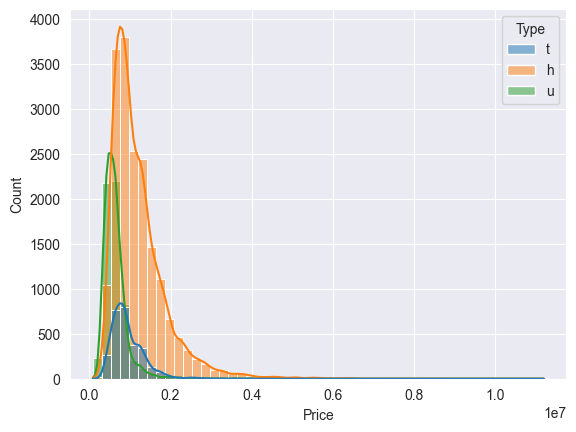

In [29]:
        sns.histplot(data=data,x='Price',color='orange', bins=50,hue='Type',kde=True)

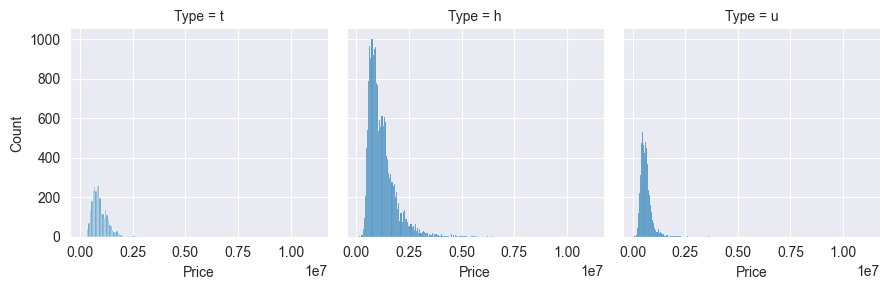

In [31]:
# how to create sub plot since the above graph is messy

g = sns.FacetGrid(data,col='Type')
g.map(sns.histplot,'Price') # one for each Type value t- townhouse , h - house , u - unit (at high level)